In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import Point

import libpysal
from libpysal.weights import KNN, DistanceBand
from esda import Moran, Moran_Local
from spreg import OLS, ML_Lag

from scipy.spatial.distance import pdist, squareform
from scipy.stats import gaussian_kde


In [5]:
df = pd.read_csv('/content/Trees_Dataset.csv')

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# Project to metric CRS for spatial analysis
gdf = gdf.to_crs(epsg=3857)

gdf.head()


,latitude,longitude,uuid,gattung_botanisch,gattung_deutsch,art_botanisch,art_deutsch,alleebaum,hoehe,stammdurchmesser,stammumfang,kronendurchmesser,baumpatenschaft,geometry
0,54.057654,12.100881,d04f4edf-c22b-481d-8140-f5da1203b9c7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1347063.919 7181082.929)
1,54.053463,12.098658,9ac13cb1-d6fa-42ae-9374-0300965a97d7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1346816.406 7180288.122)
2,54.068021,12.123567,253aad1a-c704-40fb-8401-7d88f94559d2,Quercus,Eiche,Quercus robur,Stiel-Eiche,0,18.0,35.00,109.96,12.0,0,POINT (1349589.314 7183049.253)
3,54.068164,12.113794,d7a4e358-8634-4497-988e-d2e51487d1cb,Acer,Ahorn,Acer saccharum,Zucker-Ahorn,0,20.0,50.93,160.00,9.2,0,POINT (1348501.391 7183076.331)
4,54.066913,12.117171,aa50bcd3-125c-43d5-9859-9afa368c73e0,Quercus,Eiche,Quercus rubra,Amerikanische Roteiche,1,9.0,31.83,100.00,10.0,0,POINT (1348877.355 7182838.966)


In [6]:
target = 'hoehe'

# Drop missing values in target
gdf = gdf.dropna(subset=[target])

# Optional: log-transform (helps regression stability)
gdf['log_hoehe'] = np.log1p(gdf[target])


In [7]:
coords = np.column_stack((gdf.geometry.x, gdf.geometry.y))

w = KNN.from_array(coords, k=8)
w.transform = 'r'


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 174 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [8]:
y = gdf['log_hoehe'].values

moran = Moran(y, w)

print("Global Moran's I:", moran.I)
print("p-value:", moran.p_sim)


Global Moran's I: 0.6467748506948505
p-value: 0.001


## Check from here

In [9]:
np.random.seed(42)

# Subsample 2000 points (safe for Colab)
gdf_sub = gdf.sample(n=2000, random_state=42)

coords_sub = np.column_stack((gdf_sub.geometry.x, gdf_sub.geometry.y))
y_sub = gdf_sub['log_hoehe'].values


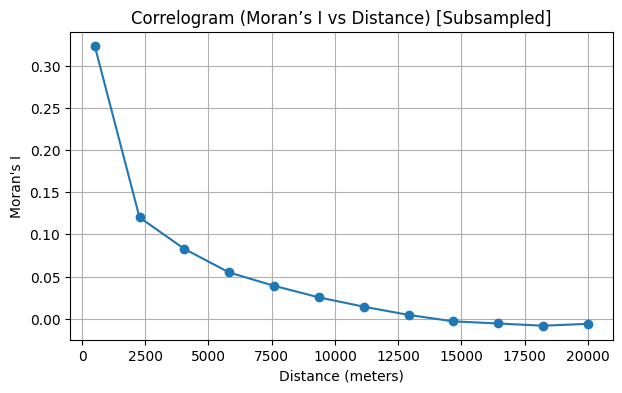

In [10]:
from libpysal.weights import DistanceBand
from esda import Moran

distances = np.linspace(500, 20000, 12)
morans = []

for d in distances:
    wd = DistanceBand.from_array(
        coords_sub,
        threshold=d,
        binary=True,
        silence_warnings=True
    )
    wd.transform = 'r'
    morans.append(Moran(y_sub, wd).I)

plt.figure(figsize=(7,4))
plt.plot(distances, morans, marker='o')
plt.xlabel("Distance (meters)")
plt.ylabel("Moran's I")
plt.title("Correlogram (Moran’s I vs Distance) [Subsampled]")
plt.grid(True)
plt.show()


In [11]:
from esda import Moran_Local

lisa = Moran_Local(y, w)

gdf['lisa_I'] = lisa.Is
gdf['lisa_p'] = lisa.p_sim
gdf['lisa_q'] = lisa.q   # quadrant labels


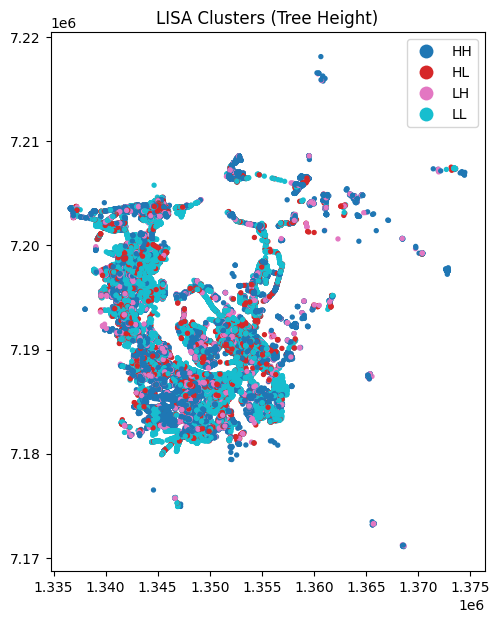

In [12]:
cluster_labels = {
    1: 'HH',
    2: 'LH',
    3: 'LL',
    4: 'HL'
}

gdf['lisa_cluster'] = gdf['lisa_q'].map(cluster_labels)

fig, ax = plt.subplots(1, 1, figsize=(7,7))
gdf.plot(
    column='lisa_cluster',
    categorical=True,
    legend=True,
    ax=ax,
    markersize=8
)
ax.set_title("LISA Clusters (Tree Height)")
#ax.axis('off')
plt.show()


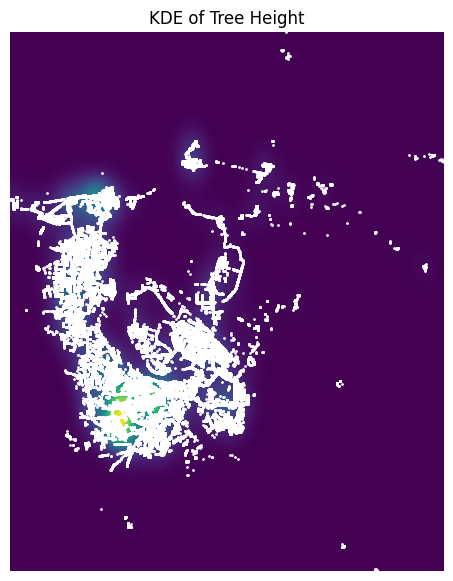

In [13]:
from scipy.stats import gaussian_kde

x = gdf.geometry.x.values
y_coords = gdf.geometry.y.values
weights = gdf['hoehe'].values

kde = gaussian_kde(np.vstack([x, y_coords]), weights=weights)

xmin, ymin, xmax, ymax = gdf.total_bounds
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])

z = kde(positions).reshape(xx.shape)

plt.figure(figsize=(7,7))
plt.imshow(
    np.rot90(z),
    cmap='viridis',
    extent=[xmin, xmax, ymin, ymax]
)
plt.scatter(x, y_coords, s=1, c='white')
plt.title("KDE of Tree Height")
plt.axis('off')
plt.show()


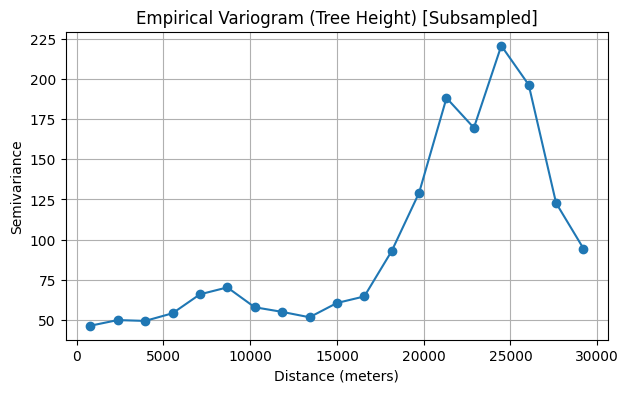

In [14]:
from scipy.spatial.distance import pdist

# Subsample for safety
gdf_var = gdf.sample(n=2000, random_state=42)

coords_var = np.column_stack((gdf_var.geometry.x, gdf_var.geometry.y))
values = gdf_var['hoehe'].values

dists = pdist(coords_var)
diffs = pdist(values.reshape(-1, 1))
semivariance = 0.5 * diffs**2

bins = np.linspace(0, 30000, 20)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
gamma = []

for i in range(len(bins)-1):
    mask = (dists >= bins[i]) & (dists < bins[i+1])
    gamma.append(np.mean(semivariance[mask]) if np.any(mask) else np.nan)

plt.figure(figsize=(7,4))
plt.plot(bin_centers, gamma, marker='o')
plt.xlabel("Distance (meters)")
plt.ylabel("Semivariance")
plt.title("Empirical Variogram (Tree Height) [Subsampled]")
plt.grid(True)
plt.show()


In [15]:
X = gdf[['kronendurchmesser', 'stammdurchmesser']].fillna(0).values
y_reg = gdf['log_hoehe'].values.reshape(-1, 1)


In [16]:
from spreg import OLS

ols = OLS(
    y_reg,
    X,
    name_y='log_hoehe',
    name_x=['crown_diam', 'trunk_diam']
)

print(ols.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_hoehe                Number of Observations:       69486
Mean dependent var  :      2.4682                Number of Variables   :           3
S.D. dependent var  :      0.5058                Degrees of Freedom    :       69483
R-squared           :      0.4801
Adjusted R-squared  :      0.4801
Sum squared residual:     9242.72                F-statistic           :  32088.1480
Sigma-square        :       0.133                Prob(F-statistic)     :           0
S.E. of regression  :       0.365                Log likelihood        :  -28509.705
Sigma-square ML     :       0.133                Akaike info criterion :   57025.411
S.E of regression ML:      0.3647                Schwarz criterion     :   57052.858

------------------------------------------------------------

In [17]:
np.random.seed(42)

gdf_reg = gdf.sample(n=3000, random_state=42)

coords_reg = np.column_stack((gdf_reg.geometry.x, gdf_reg.geometry.y))

w_reg = KNN.from_array(coords_reg, k=8)
w_reg.transform = 'r'

X_reg = gdf_reg[['kronendurchmesser', 'stammdurchmesser']].fillna(0).values
y_reg_sub = gdf_reg['log_hoehe'].values.reshape(-1, 1)

from spreg import ML_Lag

slag = ML_Lag(
    y_reg_sub,
    X_reg,
    w=w_reg,
    name_y='log_hoehe',
    name_x=['crown_diam', 'trunk_diam']
)

print(slag.summary)


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   log_hoehe                Number of Observations:        3000
Mean dependent var  :      2.4756                Number of Variables   :           4
S.D. dependent var  :      0.5039                Degrees of Freedom    :        2996
Pseudo R-squared    :      0.6107
Spatial Pseudo R-squared:  0.5458
Log likelihood      :   -823.2409
Sigma-square ML     :      0.0989                Akaike info criterion :    1654.482
S.E of regression   :      0.3145                Schwarz criterion     :    1678.507

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------

In [18]:
from spreg import GM_Lag

slag = GM_Lag(
    y_reg,
    X,
    w=w,
    name_y='log_hoehe',
    name_x=['crown_diam', 'trunk_diam']
)

print(slag.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   log_hoehe                Number of Observations:       69486
Mean dependent var  :      2.4682                Number of Variables   :           4
S.D. dependent var  :      0.5058                Degrees of Freedom    :       69482
Pseudo R-squared    :      0.7088
Spatial Pseudo R-squared:  0.5332

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.85041         0.00931        91.29528         0.00000
          crown_diam         0.05091         0.00039       129.81142         0.00000
          trunk_diam         0.00297      

In [33]:
# Predicted values
y_pred = slag.predy.flatten()
y_true = y_reg_sub.flatten()


# Residuals
residuals = slag.u.flatten()

print("Predictions shape:", y_pred.shape)
print("Residuals shape:", residuals.shape)

Predictions shape: (69486,)
Residuals shape: (69486,)
 69486


In [25]:
print("len(y_reg_sub):", len(y_reg_sub))
print("len(slag.predy):", len(slag.predy))
print("len(slag.u):", len(slag.u))


len(y_reg_sub): 3000
len(slag.predy): 69486
len(slag.u): 69486


In [37]:
from spreg import OLS

ols_sub = OLS(
    y_reg_sub,
    X_reg,   # predictors from the SAME subsample
    name_y='log_hoehe',
    name_x=['crown_diam', 'trunk_diam']
)

print(ols_sub.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_hoehe                Number of Observations:        3000
Mean dependent var  :      2.4756                Number of Variables   :           3
S.D. dependent var  :      0.5039                Degrees of Freedom    :        2997
R-squared           :      0.5125
Adjusted R-squared  :      0.5122
Sum squared residual:     371.304                F-statistic           :   1575.2903
Sigma-square        :       0.124                Prob(F-statistic)     :           0
S.E. of regression  :       0.352                Log likelihood        :   -1122.796
Sigma-square ML     :       0.124                Akaike info criterion :    2251.593
S.E of regression ML:      0.3518                Schwarz criterion     :    2269.612

------------------------------------------------------------

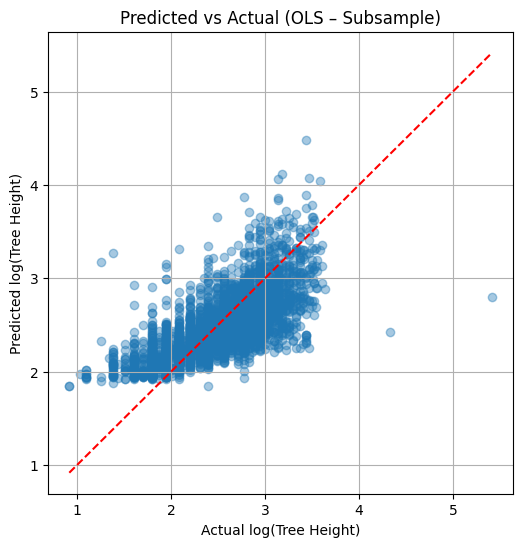

In [28]:
y_true = y_reg_sub.flatten()
y_pred_ols = ols_sub.predy.flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_ols, alpha=0.4)

min_val = min(y_true.min(), y_pred_ols.min())
max_val = max(y_true.max(), y_pred_ols.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual log(Tree Height)")
plt.ylabel("Predicted log(Tree Height)")
plt.title("Predicted vs Actual (OLS – Subsample)")
plt.grid(True)
plt.show()


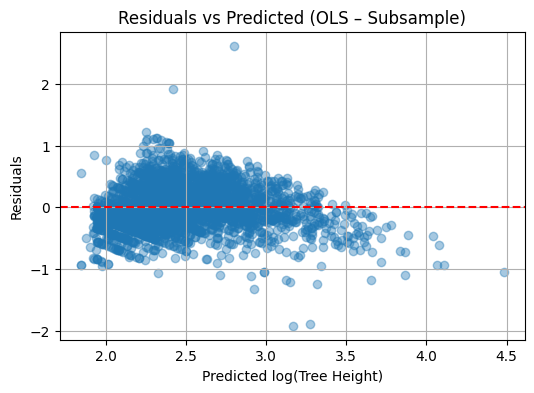

In [29]:
ols_residuals = ols_sub.u.flatten()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_ols, ols_residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted log(Tree Height)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (OLS – Subsample)")
plt.grid(True)
plt.show()


In [31]:
from esda import Moran

ols_residuals = ols_sub.u.flatten()

ols_moran = Moran(ols_residuals, w_reg)

print("OLS residual Moran’s I:", ols_moran.I)
print("p-value:", ols_moran.p_sim)


OLS residual Moran’s I: 0.2664298915238871
p-value: 0.001


In [38]:
from esda import Moran

ols_residuals = ols_sub.u.flatten()

moran_resid = Moran(ols_residuals, w_reg)

print("OLS Residual Moran’s I:", moran_resid.I)
print("p-value:", moran_resid.p_sim)


OLS Residual Moran’s I: 0.2664298915238871
p-value: 0.001


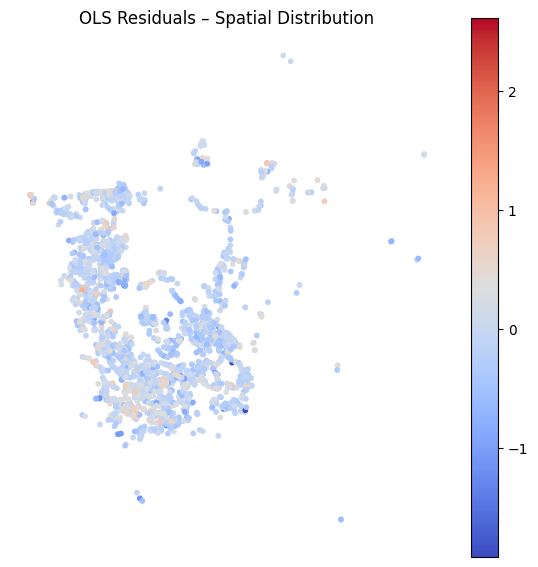

In [39]:
gdf_stationarity = gdf_reg.copy()
gdf_stationarity['ols_residuals'] = ols_residuals

fig, ax = plt.subplots(1, 1, figsize=(7,7))
gdf_stationarity.plot(
    column='ols_residuals',
    cmap='coolwarm',
    legend=True,
    ax=ax,
    markersize=10
)
ax.set_title("OLS Residuals – Spatial Distribution")
ax.axis('off')
plt.show()


In [41]:
y_reg_sub = gdf_reg['log_hoehe'].values


In [42]:
from esda import Moran_Local

lisa = Moran_Local(y_reg_sub, w_reg)

gdf_hetero = gdf_reg.copy()
gdf_hetero['lisa_q'] = lisa.q
gdf_hetero['lisa_p'] = lisa.p_sim


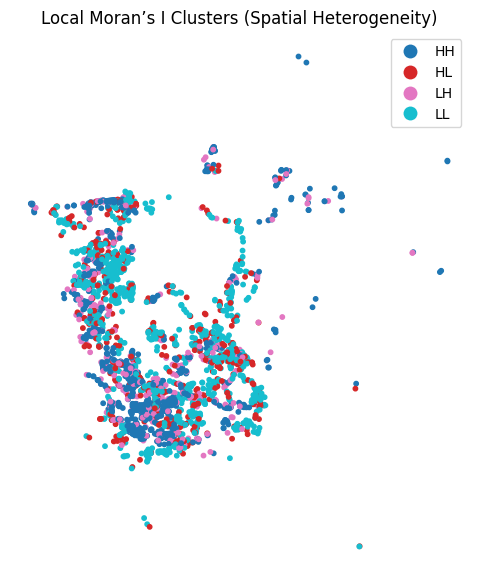

In [43]:
cluster_map = {1:'HH', 2:'LH', 3:'LL', 4:'HL'}
gdf_hetero['cluster'] = gdf_hetero['lisa_q'].map(cluster_map)

fig, ax = plt.subplots(1, 1, figsize=(7,7))
gdf_hetero.plot(
    column='cluster',
    categorical=True,
    legend=True,
    ax=ax,
    markersize=10
)
ax.set_title("Local Moran’s I Clusters (Spatial Heterogeneity)")
ax.axis('off')
plt.show()


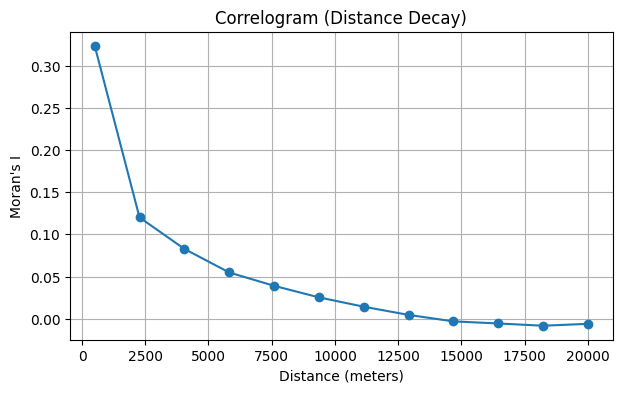

In [44]:
distances = np.linspace(500, 20000, 12)
morans = []

for d in distances:
    wd = DistanceBand.from_array(
        coords_sub,
        threshold=d,
        binary=True,
        silence_warnings=True
    )
    wd.transform = 'r'
    morans.append(Moran(y_sub, wd).I)

plt.figure(figsize=(7,4))
plt.plot(distances, morans, marker='o')
plt.xlabel("Distance (meters)")
plt.ylabel("Moran's I")
plt.title("Correlogram (Distance Decay)")
plt.grid(True)
plt.show()


## Runtime Error